# Term Paper

In [88]:
import numpy as np
import pandas as pd
import random
import scipy.stats
import chaospy 
import matplotlib.pyplot as plt
from scipy.stats import norm  


In [59]:
# Define CRRA utility function
def u(gamma, c):
    if gamma != 1 and gamma >= 0:
        return (c**(1-gamma)-1)/(1-gamma)
    else:
        return np.log(c)

In [96]:
# Create assets
N = 2 # Number of assets
mu_R = 1 + np.array([0.02, 0.03]) # Mean returns
mu_R = np.array(mu_R).reshape(N, 1)
# mu_R = np.linspace(0.02, 0.03, N) # More flexible version for more assets
Sigma_R = np.array([[0.05, 0],
                   [0, 0.15]]) # Variance-Covariance matrix
""" More powerful version for more assets:
def build_sigma(sigma = [1,.1], c=0):
    sigma=np.array(sigma).resphape(-1,1);
    d=len(sigma);
    if (c<0.0) and not (d==2):
        raise RuntimeError('build_sigma can only create negative correlation for 2 assets')
    corr=(1-c)*np.identity(d) + c*np.ones((d,d)); # correlation matrix
    Sigma=sigma*corr*sigma.T; # variance-covariance matrix
    return Sigma
"""
rho_y = np.zeros((N,1)) # correlation with income
mu_R

array([[1.02],
       [1.03]])

In [103]:
# Draw asset and income returns
def generate_draws(n=3, d=2):
    distribution = chaospy.Iid(chaospy.Uniform(0, 1), d)
    x = chaospy.generate_samples(n, domain=d, rule="random")
    w = np.full((1, x.shape[1]), 1/x.shape[1])
    return w, x

def inverse_multinormal(u, mu=None, Sigma=None):
    x = norm.ppf(u)
    if Sigma is not None:
        L = np.linalg.cholesky(Sigma)
        x = L @ x
    if mu is not None:
        mu = np.array(mu).reshape(-1, 1)
        x += mu
    return x


mu_y = 0
sigma_y = 0.1
mu = np.vstack([[mu_y], mu_R])
w, u = generate_draws(n=100, d=3)
Sigma = np.block([
            [sigma_y**2, rho_y.T @ Sigma_R],
            [Sigma_R @ rho_y, Sigma_R]
        ])
x = inverse_multinormal(u, mu=mu, Sigma=Sigma)
y = np.exp(x[0,:]).reshape(1,-1)
R = x[1:,:] 

def returns(w):
    w = np.array(w).reshape(N,1)
    R_portfolio = w.T @ R
    return R_portfolio

returns(np.ones((N,1))/N)

array([[1.06811, 0.37749, 0.61137, 0.54822, 1.04872, 1.14883, 1.21512,
        1.23643, 0.71292, 0.99603, 0.96679, 1.39201, 0.52728, 0.95104,
        0.88665, 0.69045, 1.31469, 0.41301, 1.24621, 0.78712, 0.99155,
        1.15473, 1.27952, 1.28792, 1.02541, 1.03097, 0.8883 , 0.86516,
        1.1857 , 0.64956, 1.00037, 1.09019, 1.27008, 1.0829 , 1.02957,
        0.92527, 0.95837, 1.03089, 0.85767, 1.09388, 0.99899, 1.35314,
        1.18076, 1.1194 , 1.22879, 1.03722, 1.13861, 1.33004, 1.20863,
        0.8391 , 1.30372, 0.67523, 1.03426, 0.96655, 1.20596, 0.74204,
        1.04897, 1.35818, 0.95064, 1.29428, 1.38864, 0.96686, 0.73285,
        0.88241, 1.11245, 0.68853, 1.04424, 1.37753, 1.03953, 0.67862,
        0.9051 , 0.88089, 0.81181, 1.15186, 0.71189, 0.70124, 0.77207,
        1.0437 , 1.13401, 1.05187, 0.86881, 0.87353, 1.28126, 1.29841,
        1.09849, 0.43094, 0.79608, 1.43413, 0.87821, 0.74862, 1.1274 ,
        1.35965, 1.20405, 1.022  , 0.89256, 1.16102, 1.11389, 0.8859 ,
      

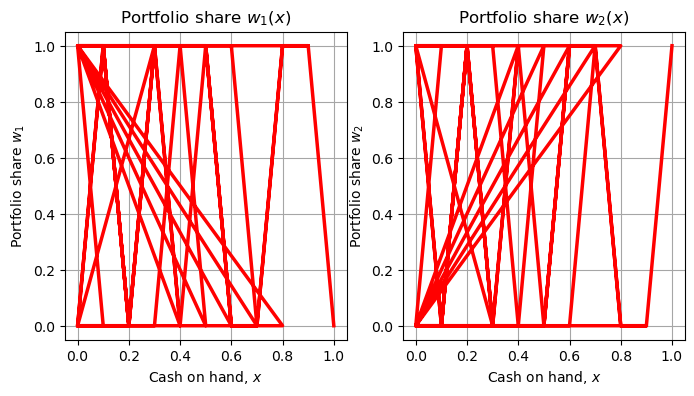

In [109]:
import numpy as np
import matplotlib.pyplot as plt

def generate_states(D, step=0.25):
    """Generate all possible portfolio weight combinations for D risky assets in increments of `step` (sum of weights <= 1)."""
    N = int(round(1.0/step))
    states = []
    combo = [0] * D
    def rec_fill(index, remaining):
        if index == D - 1:
            # Assign all remaining steps to the last asset (including 0)
            for x in range(remaining + 1):
                combo[index] = x
                states.append(tuple(c * step for c in combo))
        else:
            for x in range(0, remaining + 1):
                combo[index] = x
                rec_fill(index + 1, remaining - x)
    rec_fill(0, N)
    # Remove duplicates and sort states
    states = sorted(set(states))
    return states

def solve_portfolio_with_income(D, gamma, T, mu=None, Sigma=None, Rf=0.04, tau=0.01, Beta=0.97, grid_step=0.25, n_draws=100, mu_y=0.0, sigma_y=0.2, seed=None):
    """
    Solve the dynamic portfolio choice model with transaction costs and stochastic income via value function iteration.
    
    Parameters:
    - D (int): Number of risky assets.
    - gamma (float): Investor's risk aversion parameter (CRRA coefficient).
    - T (int): Time horizon (number of periods) for portfolio decisions.
    - mu (array-like, optional): Length-D array of expected returns for each risky asset per period.
                                 If not provided, uses baseline values for up to 5 assets.
    - Sigma (array-like, optional): DxD covariance matrix of risky asset returns per period.
                                    If not provided, uses baseline values (top-left D×D of baseline matrix).
    - Rf (float): Risk-free rate per period (e.g., 0.04 for 4%). Default 0.04.
    - tau (float): Proportional transaction cost rate. Default 0.01 (1%).
    - Beta (float): Discount factor per period. Default 0.97.
    - grid_step (float): Step size for discretizing portfolio weights. Default 0.25.
    - n_draws (int): Number of Monte Carlo draws for expectation of next-period value. Default 100.
    - mu_y (float): Mean of the log-normal distribution for income.
    - sigma_y (float): Standard deviation of the log-normal distribution for income.
    - seed (int, optional): Random seed for Monte Carlo simulation (for reproducibility).
    
    Returns:
    dict: Contains 'states' (list of state weight tuples),
          'f_values' (list of (state, value) at t=0),
          and 'policy' (list of (state, optimal_action) at t=0).
    """
    # Baseline asset parameters (from Schober et al. 2022, as cited in Gaegauf et al. 2023)  :
    baseline_mu = np.array([0.02, 0.03])
    baseline_Sigma = 1e-2 * np.array([
        [0.5, 0],
        [0, 1.5],
        ])
    # Determine asset parameters
    if mu is None or Sigma is None:
        if D > 5:
            raise ValueError("Baseline parameters are available for at most 5 assets. Please provide mu and Sigma for D > 5.")
        mu_vec = baseline_mu[:D]
        Sigma_mat = baseline_Sigma[:D, :D]
    else:
        mu_vec = np.array(mu)
        Sigma_mat = np.array(Sigma)
        if mu_vec.shape[0] != D or Sigma_mat.shape != (D, D):
            raise ValueError("Provided mu or Sigma dimensions do not match D.")
    # Set random seed if provided
    if seed is not None:
        np.random.seed(seed)
    # Discretize state space for portfolio weights
    states = generate_states(D, step=grid_step)
    N_states = len(states)
    states_array = np.array(states)
    # Initialize terminal utility: f_T(w) = 1 for all states (since V_T = U(W) and we normalize by W^(1-gamma))
    f_next = np.ones(N_states)
    optimal_policy_t0 = [None] * N_states
    f_t0 = [0.0] * N_states
    # Backward induction
    for t in range(T - 1, -1, -1):
        f_current = np.empty(N_states)
        record_policy = (t == 0)
        for i, w in enumerate(states):
            best_val = -1e18
            best_action = None
            # Sample returns for expectation (using same draws for all actions in this state for fair comparison)
            draws = np.random.multivariate_normal(mu_vec, Sigma_mat, size=n_draws)
            factors = 1.0 + draws              # shape (n_draws, D)
            rf_factor = 1.0 + Rf               # scalar
            # Sample income from log-normal distribution
            income = np.random.lognormal(mu_y, sigma_y, size=n_draws)
            for j, w_prime in enumerate(states):
                # Transaction cost fraction for rebalancing from w to w_prime
                diff = np.array(w_prime) - np.array(w)
                cost_frac = tau * np.sum(np.abs(diff))
                if cost_frac >= 1.0:
                    # skip actions that consume all wealth or more in transaction costs
                    continue
                # Effective wealth multiplier after paying transaction cost
                cost_factor = (1.0 - cost_frac) ** (1 - gamma)
                # Compute wealth growth factor and next-state weights for each return scenario
                w_prime_arr = np.array(w_prime)
                sum_w_prime = np.sum(w_prime_arr)
                risky_growth = factors.dot(w_prime_arr)                    # (n_draws,) sum_i w'_i * (1+R_i)
                R_totals = risky_growth + (1.0 - sum_w_prime) * rf_factor  # (n_draws,) total growth factor
                numerators = factors * w_prime_arr                        # (n_draws, D) each = w'_i * (1+R_i)
                w_next_arr = numerators / R_totals[:, None]               # (n_draws, D) next-period risky weights
                # Compute expected next value E[ R_total^(1-gamma) * f_next(w_{t+1}) ]
                values_next = np.zeros(n_draws)
                for k in range(n_draws):
                    w_next = w_next_arr[k]
                    # Find nearest grid state to w_next
                    diffs = states_array - w_next
                    dist2 = np.sum(diffs**2, axis=1)
                    nearest_idx = np.argmin(dist2)
                    values_next[k] = f_next[nearest_idx]
                expected_val = np.mean((R_totals ** (1 - gamma)) * values_next + income)  # Add income to value
                total_val = Beta * cost_factor * expected_val
                if total_val > best_val:
                    best_val = total_val
                    best_action = w_prime
            f_current[i] = best_val
            if record_policy:
                optimal_policy_t0[i] = (w, best_action)
        # Update for next iteration (move backward in time)
        f_next = f_current.copy()
        if record_policy:
            f_t0 = f_current.copy()
    return {
        'states': states,
        'f_values': [(states[i], f_t0[i]) for i in range(N_states)],
        'policy': optimal_policy_t0
    }

def w_plot_against_cash_on_hand(policy, D, grid_step=0.25):
    '''Illustrate solution for portfolio shares against cash-on-hand'''
    # Extract portfolio shares and cash-on-hand
    cash_on_hand = []
    portfolio_shares = np.zeros((len(policy), D))
    
    for i, (w, best_action) in enumerate(policy):
        cash_on_hand.append(1 - sum(w))  # Cash on hand = 1 - sum of risky asset shares
        portfolio_shares[i] = best_action
    
    # Plot portfolio shares against cash-on-hand
    fig, ax = plt.subplots(1, D, figsize=(4 * D, 4))  # One subplot per asset
    if D == 1:  # Ensure ax is iterable even for a single asset
        ax = [ax]
        
    for j in range(D):
        ax[j].grid(which='both', color='0.65', linestyle='-')
        ax[j].set_title(f'Portfolio share $w_{j+1}(x)$')
        ax[j].set_xlabel('Cash on hand, $x$')
        ax[j].set_ylabel(f'Portfolio share $w_{j+1}$')
        ax[j].plot(cash_on_hand, portfolio_shares[:, j], color='r', linewidth=2.5)

    plt.show()

# Example usage
if __name__ == "__main__":
    result = solve_portfolio_with_income(D=2, gamma=2, T=10, grid_step=0.1, n_draws=100, mu_y=0.0, sigma_y=0.1, seed=0)
    w_plot_against_cash_on_hand(result['policy'], D=2)
